### Figure S6

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
import zipfile
import warnings
import fed3bandit as f3b
import copy
from pandas.api.types import CategoricalDtype
from scipy.stats import ttest_rel, ttest_ind
from osfclient import OSF

warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.size': 32, 
    'figure.autolayout': True, 
    'lines.linewidth': 2, 
    'axes.spines.top': False, 
    'axes.spines.right': False
    })

cat_size_order = CategoricalDtype(["Sal", "MK801"], ordered=True)

Define Functions

In [34]:
def count_pellets(data_choices):
    """Counts the number of pellets in fed3 data file
    
    Parameters
    ----------
    data_choices : pandas.DataFrame
        The fed3 data file

    Returns
    --------
    c_pellets : int
        total number of pellets
    """

    f_data_choices = f3b.filter_data(data_choices)
    pellet_count = f_data_choices["Pellet_Count"]
      
    c_diff = np.diff(pellet_count)
    c_diff2 = np.where(c_diff < 0, 1, c_diff)
    c_pellets = int(c_diff2.sum())
    
    return c_pellets

def win_stay(data_choices):
    """Calculates the win-stay probaility
    
    Parameters
    ----------
    data_choices : pandas.DataFrame
        The fed3 data file

    Returns
    --------
    win_stay_p : int
        win-stay probability
    """
    f_data_choices = f3b.filter_data(data_choices)
    pellet_count = f_data_choices["Pellet_Count"]
    events = f_data_choices["Event"]
        
    win_stay = 0
    win_shift = 0
    for i in range(f_data_choices.shape[0]-1):
        c_choice = events.iloc[i]
        next_choice = events.iloc[i+1]
        c_count = pellet_count.iloc[i]
        next_count = pellet_count.iloc[i+1]
        if np.logical_or(next_count-c_count == 1, next_count-c_count < 0):
            c_outcome = 1
        else:
            c_outcome = 0
            
        if c_outcome == 1:
            if ((c_choice == "Left") and (next_choice == "Left")):
                win_stay += 1
            elif ((c_choice == "Right") and (next_choice == "Right")):
                win_stay += 1
            elif((c_choice == "Left") and (next_choice == "Right")):
                win_shift += 1
            elif((c_choice == "Right") and (next_choice == "Left")):
                win_shift += 1
                
    if (win_stay+win_shift) == 0:
        win_stay_p = np.nan
    else:
        win_stay_p = win_stay / (win_stay + win_shift)
    
    return win_stay_p

def lose_shift(data_choices):
    """Calculates the lose-shift probaility
    
    Parameters
    ----------
    data_choices : pandas.DataFrame
        The fed3 data file

    Returns
    --------
    lose_shift_p : int
        lose-shift probability
    """
    f_data_choices = f3b.filter_data(data_choices)
    block_pellet_count = f_data_choices["Pellet_Count"]
    events = f_data_choices["Event"]
    
    lose_stay = 0
    lose_shift = 0
    for i in range(f_data_choices.shape[0]-1):
        c_choice = events.iloc[i]
        next_choice = events.iloc[i+1]
        c_count = block_pellet_count.iloc[i]
        next_count = block_pellet_count.iloc[i+1]
        if np.logical_or(next_count-c_count == 1, next_count-c_count == -19):
            c_outcome = 1
        else:
            c_outcome = 0
            
        if c_outcome == 0:
            if ((c_choice == "Left") and (next_choice == "Left")):
                lose_stay += 1
            elif ((c_choice == "Right") and (next_choice == "Right")):
                lose_stay += 1
            elif((c_choice == "Left") and (next_choice == "Right")):
                lose_shift += 1
            elif((c_choice == "Right") and (next_choice == "Left")):
                lose_shift += 1
                 
    if (lose_shift+lose_stay) == 0:
        lose_shift_p = np.nan
    else:
        lose_shift_p = lose_shift / (lose_shift + lose_stay)
    
    return lose_shift_p

Fetching data from OSF and extracting it

In [35]:
# Create output directory
output_dir = "osf_downloads"
os.makedirs(output_dir, exist_ok=True)

# Connect to OSF
osf = OSF()
project = osf.project('stk2r')
storage = project.storage('osfstorage')

# Set up folder name with data
target_filename = 'Figure_S6_data.zip'

# Download zip file with data
for file in storage.files:
    if file.name == target_filename:
        output_path = os.path.join(output_dir, file.name)
        with open(output_path, 'wb') as f:
            file.write_to(f)
        print(f"Downloaded: {file.name} to {output_path}")
        break
else:
    print(f"File '{target_filename}' not found in OSF storage.")

#Set up 
zip_path = 'osf_downloads/Figure_S6_data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted all files to {output_dir}")

100%|██████████| 153k/153k [00:00<00:00, 1.07Mbytes/s]

Downloaded: Figure_S6_data.zip to osf_downloads\Figure_S6_data.zip
Extracted all files to osf_downloads


Formatting the data for analysis and adding injection times

In [36]:
fileloc = os.path.join(os.getcwd(), "osf_downloads", "Figure_S6_data")

#Saline intrastriatal dataset
saline_icv_data = {
    "saline_1": {
        "C109M1": pd.read_csv(fileloc + "/saline_icv_FR1_C109M1_120423.csv"),
        "C109M2": pd.read_csv(fileloc + "/saline_icv_FR1_C109M2_120423.csv")
    },
    "saline_2": {
        "C109M3": pd.read_csv(fileloc + "/saline_icv_FR1_C109M3_121123.csv"),
        "C109M4": pd.read_csv(fileloc + "/saline_icv_FR1_C109M4_121123.csv"),
        "C92M3": pd.read_csv(fileloc + "/saline_icv_FR1_C92M3_121123.csv")
    }
}
saline_icv_injectiontimes = {
    "saline_1": datetime.datetime(2023, 12, 4, 18, 50),
    "saline_2": datetime.datetime(2023, 12, 11, 20, 20)
    }

#MK801 intrastriatal dataset
mk801_icv_data = {
    "mk801_1": {
        "C109M3": pd.read_csv(fileloc + "/mk801_icv_FR1_C109M3_120423.csv"),
        "C109M4": pd.read_csv(fileloc + "/mk801_icv_FR1_C109M4_120423.csv"),
        "C92M3": pd.read_csv(fileloc + "/mk801_icv_FR1_C92M3_120423.csv")
    },
    "mk801_2": {
        "C109M1": pd.read_csv(fileloc + "/mk801_icv_FR1_C109M1_121123.csv"),
        "C109M2": pd.read_csv(fileloc + "/mk801_icv_FR1_C109M2_121123.csv")
    }
}
mk801_icv_injectiontimes = {
    "mk801_1": datetime.datetime(2023, 12, 4, 23, 15),
    "mk801_2": datetime.datetime(2023, 12, 11, 20, 20)
    }

#Saline systemic dataset
saline_syst_data = {
    "saline_1": {
        "C109M1": pd.read_csv(fileloc + "/saline_syst_FR1_C109M1_111723.csv"),
        "C109M2": pd.read_csv(fileloc + "/saline_syst_FR1_C109M2_111723.csv"),
    },
    "saline_2": {
        "C109M3": pd.read_csv(fileloc + "/saline_syst_FR1_C109M3_112523.csv"),
        "C109M4": pd.read_csv(fileloc + "/saline_syst_FR1_C109M4_112523.csv"),
        "C92M3": pd.read_csv(fileloc + "/saline_syst_FR1_C92M3_112523.csv")
    }
}

saline_syst_injectiontimes = {
    "saline_1": datetime.datetime(2023, 11, 17, 22, 45),
    "saline_2": datetime.datetime(2023, 11, 25, 21, 30)
}

# MK801 systemic dataset
mk801_syst_data = {
    "mk801_1": {
        "C109M3": pd.read_csv(fileloc + "/mk801_syst_FR1_C109M3_111523.csv"),
        "C109M4": pd.read_csv(fileloc + "/mk801_syst_FR1_C109M4_111523.csv"),
        "C92M3": pd.read_csv(fileloc + "/mk801_syst_FR1_C92M3_111723.csv"),
    },
    "mk801_2": {
        "C109M1": pd.read_csv(fileloc + "/mk801_syst_FR1_C109M1_112523.csv"),
        "C109M2": pd.read_csv(fileloc + "/mk801_syst_FR1_C109M2_112523.csv")
    }
}

mk801_syst_injectiontimes = {
    "mk801_1": datetime.datetime(2023, 11, 17, 22, 45),
    "mk801_2": datetime.datetime(2023, 11, 25, 21, 30)
    }

Data pre-processing

In [37]:
"""
First, we filter out events to only include valid pokes ("Left" and "Right" events").
Then, we make sure that the first column is of datetime type
"""

#Saline intrastriatal
p_saline_icv_data = {}
for session in saline_icv_data:
    c_session = saline_icv_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_saline_icv_data[session] = p_session

#Fixing wrong time in C84M1
p_saline_icv_data["saline_2"]["C109M3"].iloc[:,0] = p_saline_icv_data["saline_2"]["C109M3"].iloc[:,0] - datetime.timedelta(hours=1, minutes=10)

#MK801 intrastriatal
p_mk801_icv_data = {}
for session in mk801_icv_data:
    c_session = mk801_icv_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_mk801_icv_data[session] = p_session

#Fixing wrong time in C84M1
p_mk801_icv_data["mk801_1"]["C109M3"].iloc[:,0] = p_mk801_icv_data["mk801_1"]["C109M3"].iloc[:,0] - datetime.timedelta(hours=1, minutes=10)

#Saline systemic
p_saline_syst_data = {}
for session in saline_syst_data:
    c_session = saline_syst_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_saline_syst_data[session] = p_session

#MK801 systemic
p_mk801_syst_data = {}
for session in mk801_syst_data:
    c_session = mk801_syst_data[session]
    p_session = {}
    for mouse in c_session:
        f_mouse = f3b.filter_data(c_session[mouse])
        f_mouse.iloc[:,0] = pd.to_datetime(f_mouse.iloc[:,0])
        p_session[mouse] = f_mouse
    
    p_mk801_syst_data[session] = p_session

print("All files have been successfully filtered and pre-processed")

All files have been successfully filtered and pre-processed


In [38]:
"""Slice data to only eight hours after intra-striatal infusion (or injection)."""

post_hours = 8

#Saline intrastriatal
saline_icv_slices = {}
for session in p_saline_icv_data:
    c_session = p_saline_icv_data[session]
    c_injection = saline_icv_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    saline_icv_slices[session] = s_session

#Mk801 intrastriatal
mk801_icv_slices = {}
for session in p_mk801_icv_data:
    c_session = p_mk801_icv_data[session]
    c_injection = mk801_icv_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    mk801_icv_slices[session] = s_session

#saline systemic
saline_syst_slices = {}
for session in p_saline_syst_data:
    c_session = p_saline_syst_data[session]
    c_injection = saline_syst_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    saline_syst_slices[session] = s_session

#MK801 systemic
mk801_syst_slices = {}
for session in p_mk801_syst_data:
    c_session = p_mk801_syst_data[session]
    c_injection = mk801_syst_injectiontimes[session]
    s_session = {mouse: c_session[mouse][np.logical_and(c_session[mouse].iloc[:,0] < c_injection + datetime.timedelta(hours=post_hours),
                                                        c_session[mouse].iloc[:,0] > c_injection)] for mouse in c_session}
    mk801_syst_slices[session] = s_session

print("All files have been successfully filtered and sliced")

All files have been successfully filtered and sliced


Example traces for intra-striatal experiment. Figure S6B

(-4.95, 103.95, 0.0, 1.0)

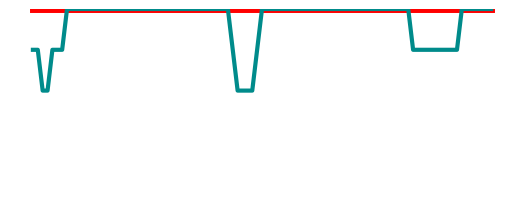

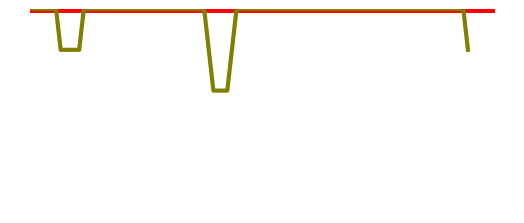

In [39]:
#Saline
saline_icv_sample = saline_icv_slices["saline_1"]["C109M1"].iloc[:100,:]
saline_icv_bactions = f3b.binned_paction(saline_icv_sample)
saline_icv_true = np.ones(len(saline_icv_bactions))

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(saline_icv_true, c="red", linewidth=5)
ax.plot(saline_icv_bactions, c="darkcyan", linewidth=3)
ax.set_ylim(0,1)
plt.axis("off")

#MK801
mk801_icv_sample = mk801_icv_slices["mk801_2"]["C109M1"].iloc[:100,:]
mk801_icv_bactions = f3b.binned_paction(mk801_icv_sample)
mk801_icv_true = np.ones(mk801_icv_sample.shape[0])

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(mk801_icv_true, c="red", linewidth=5)
ax.plot(mk801_icv_bactions, c="olive", linewidth=3)
ax.set_ylim(0,1)
plt.axis("off")

Calculation of pokes, pellets, and win-stay metrics for intrastriatal data.
For documentation and source code of FED3Bandit package, which is used to calculate metrics, please see:

FED3Bandit package documentation: https://fed3bandit.readthedocs.io/en/latest/analysis/fed3live_api.html

FED3Bandit package source code:  https://github.com/AlexLM96/fed3bandit/blob/main/fed3bandit/fed3bandit/fed3bandit.py


In [57]:
#Saline intrastriatal metrics
saline_icv_pellets = {}
saline_icv_pokes = {}
saline_icv_ws = {}
for session in saline_icv_slices:
    c_session = saline_icv_slices[session]

    #Calculate metrics
    c_session_icv_pellets = {mouse: [count_pellets(c_session[mouse])] for mouse in c_session}
    c_session_icv_pokes = {mouse: [f3b.count_pokes(c_session[mouse])] for mouse in c_session}
    c_session_icv_ws = {mouse: [win_stay(c_session[mouse])] for mouse in c_session}

    saline_icv_pellets = saline_icv_pellets | c_session_icv_pellets
    saline_icv_pokes = saline_icv_pokes | c_session_icv_pokes
    saline_icv_ws = saline_icv_ws | c_session_icv_ws

saline_icv_pellets = pd.DataFrame(saline_icv_pellets).T
saline_icv_pokes = pd.DataFrame(saline_icv_pokes).T
saline_icv_ws = pd.DataFrame(saline_icv_ws).T

#MK801 intrastriatal metrics
mk801_icv_pellets = {}
mk801_icv_pokes = {}
mk801_icv_ws = {}
for session in mk801_icv_slices:
    c_session = mk801_icv_slices[session]

    #Calculate metrics
    c_session_icv_pellets = {mouse: [count_pellets(c_session[mouse])] for mouse in c_session}
    c_session_icv_pokes = {mouse: [f3b.count_pokes(c_session[mouse])] for mouse in c_session}
    c_session_icv_ws = {mouse: [win_stay(c_session[mouse])] for mouse in c_session}

    mk801_icv_pellets = mk801_icv_pellets | c_session_icv_pellets
    mk801_icv_pokes = mk801_icv_pokes | c_session_icv_pokes
    mk801_icv_ws = mk801_icv_ws | c_session_icv_ws

mk801_icv_pellets = pd.DataFrame(mk801_icv_pellets).T
mk801_icv_pokes = pd.DataFrame(mk801_icv_pokes).T
mk801_icv_ws = pd.DataFrame(mk801_icv_ws).T

print("All metrics were successfully calculated")


All metrics were successfully calculated


Concatenating metrics and preparing for plotting

In [58]:
# Pellets
all_icv_pellets = pd.concat([saline_icv_pellets, mk801_icv_pellets], axis=1).reset_index()
all_icv_pellets.columns = ["Mouse", "Sal", "MK801"]
m_all_icv_pellets = pd.melt(all_icv_pellets, id_vars="Mouse")
m_all_icv_pellets["variable"] = m_all_icv_pellets["variable"].astype(cat_size_order)
m_all_icv_pellets = m_all_icv_pellets.sort_values(by="variable")

# Pokes
all_icv_pokes = pd.concat([saline_icv_pokes, mk801_icv_pokes], axis=1).reset_index()
all_icv_pokes.columns = ["Mouse", "Sal", "MK801"]
m_all_icv_pokes = pd.melt(all_icv_pokes, id_vars="Mouse")
m_all_icv_pokes["variable"] = m_all_icv_pokes["variable"].astype(cat_size_order)
m_all_icv_pokes = m_all_icv_pokes.sort_values(by="variable")

# Percent left (calculated as (1/pokes_per_pellet)*100, given that it is an FR1 task)
m_all_icv_ppp = copy.deepcopy(m_all_icv_pokes)
m_all_icv_ppp["value"] = m_all_icv_pokes["value"] / m_all_icv_pellets["value"]

left_icv_prcnt = copy.deepcopy(m_all_icv_ppp)
left_icv_prcnt["value"] = 1/left_icv_prcnt["value"] * 100

#Win-stay
all_icv_ws = pd.concat([saline_icv_ws, mk801_icv_ws], axis=1).reset_index()
all_icv_ws.columns = ["Mouse", "Sal", "MK801"]
m_all_icv_ws = pd.melt(all_icv_ws, id_vars="Mouse")
m_all_icv_ws["variable"] = m_all_icv_ws["variable"].astype(cat_size_order)
m_all_icv_ws = m_all_icv_ws.sort_values(by="variable")

print("Metrics were succesfully reformatted and are ready to be plotted")


Metrics were succesfully reformatted and are ready to be plotted


Intrastriatal Pellets plot and statistics (Figure S6C)

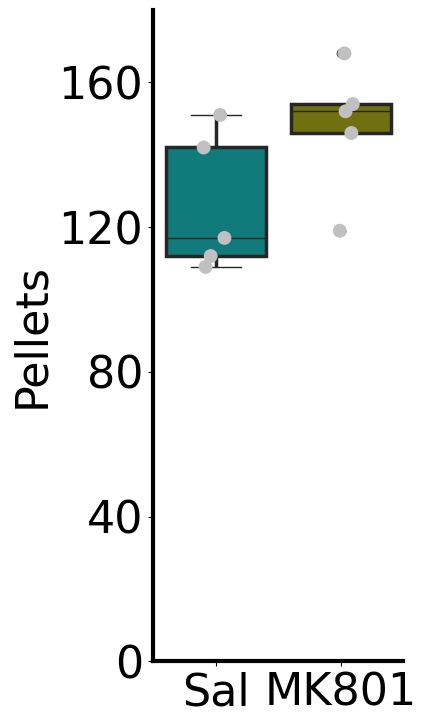

In [59]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_icv_pellets, palette=[
            "darkcyan", "olive", "salmon"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=m_all_icv_pellets, palette=["silver", "silver", "silver"], s=10)
ax.set_ylabel("Pellets")
ax.set_xlabel("")
sns.despine()
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
ax.set_ylim(0,180)
ax.set_yticks(np.arange(0,180,40))

mk801_pellets_ttest = ttest_rel(m_all_icv_pellets["value"][m_all_icv_pellets["variable"]== "Sal"], 
                                m_all_icv_pellets["value"][m_all_icv_pellets["variable"] == "MK801"])


Intrastriatal Pokes plot and statistics (Figure S6D)

TtestResult(statistic=-3.0544731127434503, pvalue=0.037862321931848, df=4)


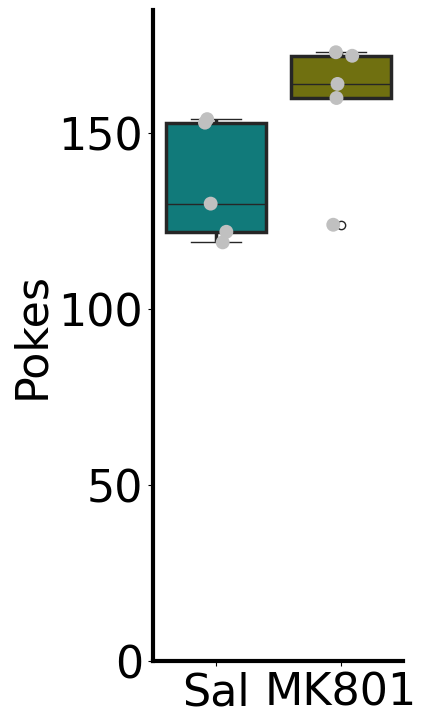

In [49]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_icv_pokes, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=m_all_icv_pokes, palette=["silver", "silver"], s=10)
ax.set_ylabel("Pokes")
ax.set_xlabel("")
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
ax.set_ylim(0,185)
sns.despine()

mk801_pokes_ttest = ttest_rel(m_all_icv_pokes["value"][m_all_icv_pokes["variable"]== "Sal"], 
                                m_all_icv_pokes["value"][m_all_icv_pokes["variable"] == "MK801"])
print(mk801_pokes_ttest)

Intrastriatal %Left plot and statistics (Figure S6E)

(45.0, 100.0)

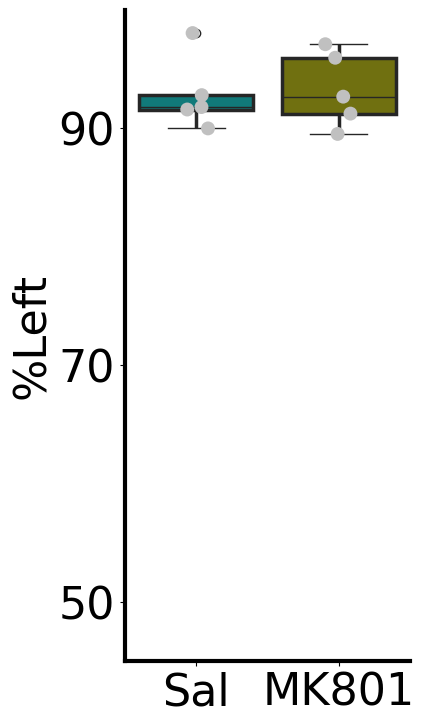

In [50]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=left_icv_prcnt, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=left_icv_prcnt, palette=["silver", "silver"], s=10)
ax.set_ylabel("%Left")
ax.set_xlabel("")
ax.set_yticks(np.arange(50,100,20))
sns.despine()
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
ax.set_ylim(45,100)

Intrastriatal Win-stay plot and statistics (Figure S6F)

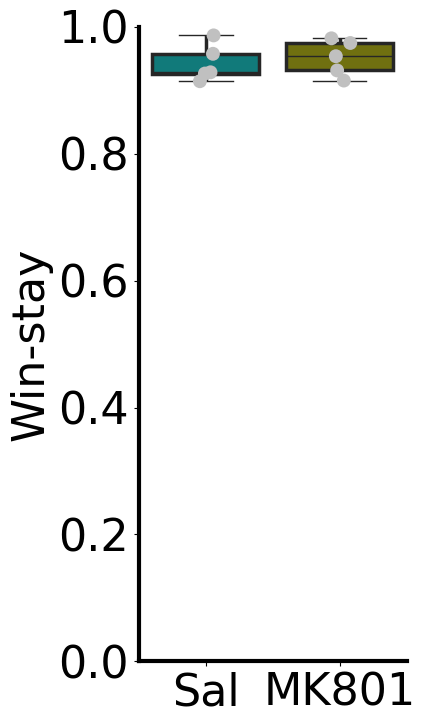

In [51]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_icv_ws, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=m_all_icv_ws, palette=["silver", "silver"], s=10, jitter=True)
ax.set_ylabel("Win-stay")
ax.set_xlabel("")
ax.set_ylim(0,1)
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
sns.despine()

Example traces for systemic experiment. Figure S6H

(-9.55, 200.55, 0.0, 1.0)

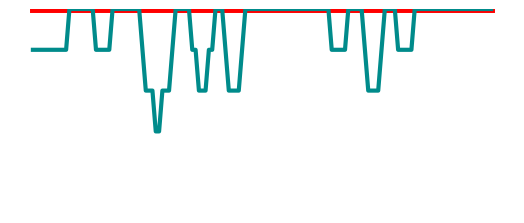

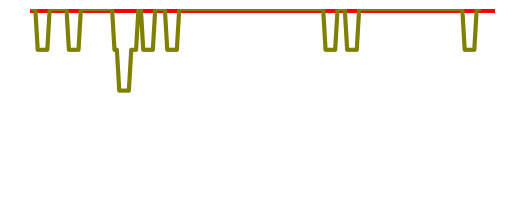

In [52]:
saline_syst_sample = saline_syst_slices["saline_1"]["C109M2"].iloc[:,:]
saline_syst_bactions = f3b.binned_paction(saline_syst_sample)
saline_syst_true = np.ones(len(saline_syst_bactions))

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(saline_syst_true, c="red", linewidth=5)
ax.plot(saline_syst_bactions, c="darkcyan", linewidth=3)
ax.set_ylim(0,1)
plt.axis("off")

mk801_syst_sample = mk801_syst_slices["mk801_2"]["C109M2"].iloc[:,:]
mk801_syst_bactions = f3b.binned_paction(mk801_syst_sample)
mk801_syst_true = np.ones(mk801_syst_sample.shape[0])

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(mk801_syst_true, c="red", linewidth=5)
ax.plot(mk801_syst_bactions, c="olive", linewidth=3)
ax.set_ylim(0,1)
plt.axis("off")

Calculation of pokes, pellets, and win-stay metrics for systemic data.
For documentation and source code of FED3Bandit package, which is used to calculate metrics, please see:

FED3Bandit package documentation: https://fed3bandit.readthedocs.io/en/latest/analysis/fed3live_api.html

FED3Bandit package source code:  https://github.com/AlexLM96/fed3bandit/blob/main/fed3bandit/fed3bandit/fed3bandit.py


In [60]:
#Saline systemic metrics
saline_syst_pellets = {}
saline_syst_pokes = {}
saline_syst_ws = {}
for session in saline_syst_slices:
    c_session = saline_syst_slices[session]

    #Calculate metrics
    c_session_syst_pellets = {mouse: [count_pellets(c_session[mouse])] for mouse in c_session}
    c_session_syst_pokes = {mouse: [f3b.count_pokes(c_session[mouse])] for mouse in c_session}
    c_session_syst_ws = {mouse: [win_stay(c_session[mouse])] for mouse in c_session}

    saline_syst_pellets = saline_syst_pellets | c_session_syst_pellets
    saline_syst_pokes = saline_syst_pokes | c_session_syst_pokes
    saline_syst_ws = saline_syst_ws | c_session_syst_ws

saline_syst_pellets = pd.DataFrame(saline_syst_pellets).T
saline_syst_pokes = pd.DataFrame(saline_syst_pokes).T
saline_syst_ws = pd.DataFrame(saline_syst_ws).T

#MK801 systemic metrics
mk801_syst_pellets = {}
mk801_syst_pokes = {}
mk801_syst_ws = {}
for session in mk801_syst_slices:
    c_session = mk801_syst_slices[session]

    #Calculate metrics
    c_session_syst_pellets = {mouse: [count_pellets(c_session[mouse])] for mouse in c_session}
    c_session_syst_pokes = {mouse: [f3b.count_pokes(c_session[mouse])] for mouse in c_session}
    c_session_syst_ws = {mouse: [win_stay(c_session[mouse])] for mouse in c_session}

    mk801_syst_pellets = mk801_syst_pellets | c_session_syst_pellets
    mk801_syst_pokes = mk801_syst_pokes | c_session_syst_pokes
    mk801_syst_ws = mk801_syst_ws | c_session_syst_ws

mk801_syst_pellets = pd.DataFrame(mk801_syst_pellets).T
mk801_syst_pokes = pd.DataFrame(mk801_syst_pokes).T
mk801_syst_ws = pd.DataFrame(mk801_syst_ws).T

print("All metrics were successfully calculated")

All metrics were successfully calculated


In [61]:
# Pellets
all_syst_pellets = pd.concat([saline_syst_pellets, mk801_syst_pellets], axis=1).reset_index()
all_syst_pellets.columns = ["Mouse", "Sal", "MK801"]
m_all_syst_pellets = pd.melt(all_syst_pellets, id_vars="Mouse")
m_all_syst_pellets["variable"] = m_all_syst_pellets["variable"].astype(cat_size_order)
m_all_syst_pellets = m_all_syst_pellets.sort_values(by="variable")

# Pokes
all_syst_pokes = pd.concat([saline_syst_pokes, mk801_syst_pokes], axis=1).reset_index()
all_syst_pokes.columns = ["Mouse", "Sal", "MK801"]
m_all_syst_pokes = pd.melt(all_syst_pokes, id_vars="Mouse")
m_all_syst_pokes["variable"] = m_all_syst_pokes["variable"].astype(cat_size_order)
m_all_syst_pokes = m_all_syst_pokes.sort_values(by="variable")

# Percent left (calculated as (1/pokes_per_pellet)*100, given that it is an FR1 task)
m_all_syst_ppp = copy.deepcopy(m_all_syst_pokes)
m_all_syst_ppp["value"] = m_all_syst_pokes["value"] / m_all_syst_pellets["value"]

left_syst_prcnt = copy.deepcopy(m_all_syst_ppp)
left_syst_prcnt["value"] = 1/left_syst_prcnt["value"] * 100

#Win-stay
all_syst_ws = pd.concat([saline_syst_ws, mk801_syst_ws], axis=1).reset_index()
all_syst_ws.columns = ["Mouse", "Sal", "MK801"]
m_all_syst_ws = pd.melt(all_syst_ws, id_vars="Mouse")
m_all_syst_ws["variable"] = m_all_syst_ws["variable"].astype(cat_size_order)
m_all_syst_ws = m_all_syst_ws.sort_values(by="variable")

print("Metrics were succesfully reformatted and are ready to be plotted")

Metrics were succesfully reformatted and are ready to be plotted


Systemic Pellets plot and statistics (Figure S6I)

TtestResult(statistic=-2.467580754771664, pvalue=0.06912607731920732, df=4)


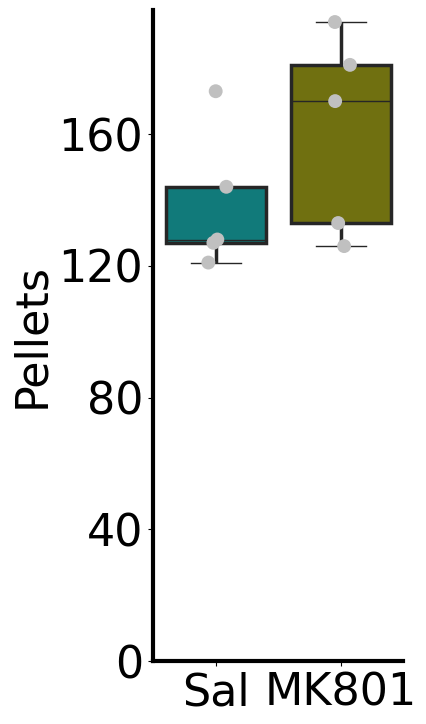

In [67]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_syst_pellets, palette=[
            "darkcyan", "olive", "salmon"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=m_all_syst_pellets, palette=["silver", "silver", "silver"], s=10)
ax.set_ylabel("Pellets")
ax.set_xlabel("")
sns.despine()
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
#ax.set_ylim(0,180)
ax.set_yticks(np.arange(0,180,40))

mk801_pellets_ttest = ttest_rel(m_all_syst_pellets["value"][m_all_syst_pellets["variable"]== "Sal"], 
                                m_all_syst_pellets["value"][m_all_syst_pellets["variable"] == "MK801"])
print(mk801_pellets_ttest)

Systemic Pokes plot and statistics (Figure S6J)

TtestResult(statistic=-3.0561270572208454, pvalue=0.03780119097376039, df=4)


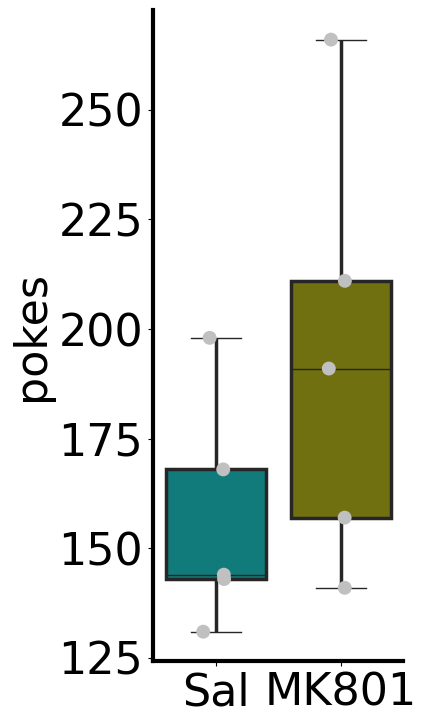

In [68]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_syst_pokes, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=m_all_syst_pokes, palette=["silver", "silver"], s=10)
ax.set_ylabel("pokes")
ax.set_xlabel("")
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
sns.despine()

mk801_pokes_ttest = ttest_rel(m_all_syst_pokes["value"][m_all_syst_pokes["variable"]== "Sal"], 
                              m_all_syst_pokes["value"][m_all_syst_pokes["variable"] == "MK801"])
print(mk801_pokes_ttest)

Systemic %Left plot and statistics (Figure S6K)

TtestResult(statistic=0.9517357218017359, pvalue=0.39512512338860495, df=4)


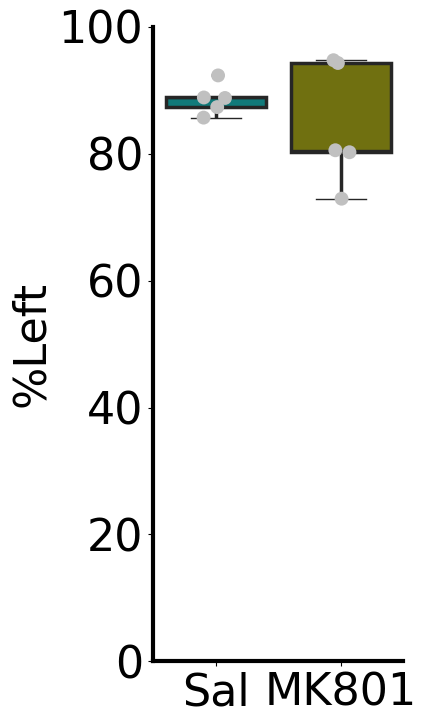

In [69]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=left_syst_prcnt, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=left_syst_prcnt, palette=["silver", "silver"], s=10)
ax.set_ylabel("%Left")
ax.set_xlabel("")
#ax.set_yticks(np.arange(0,100,20))
sns.despine()
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
ax.set_ylim(0,100)

left_percent_syst_ttest = ttest_rel(left_syst_prcnt["value"][left_syst_prcnt["variable"]== "Sal"], left_syst_prcnt["value"][left_syst_prcnt["variable"] == "MK801"])
print(left_percent_syst_ttest)

Systemic Win-stay plot and statistics (Figure S6L)

TtestResult(statistic=0.47667145262073596, pvalue=0.6584679686050815, df=4)


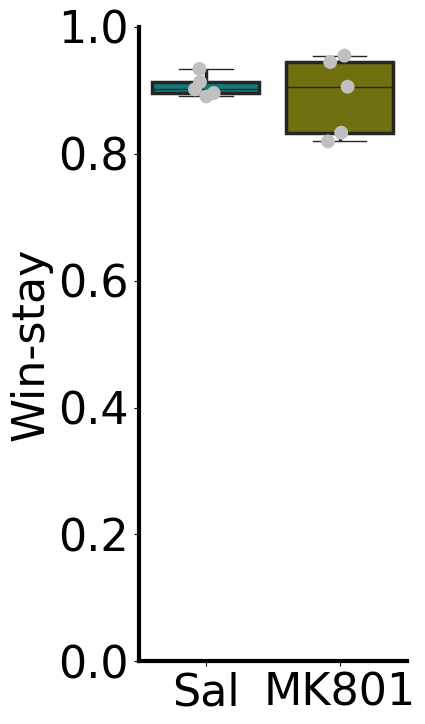

In [70]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.boxplot(x="variable", y="value", data=m_all_syst_ws, palette=[
            "darkcyan", "olive"], boxprops={"linewidth": 2.5}, whiskerprops={"linewidth": 2.5})
sns.stripplot(x="variable", y="value", data=m_all_syst_ws, palette=["silver", "silver"], s=10, jitter=True)
ax.set_ylabel("Win-stay")
ax.set_xlabel("")
ax.set_ylim(0,1)
ax.spines["bottom"].set_linewidth(3)
ax.spines["left"].set_linewidth(3)
sns.despine()

mk801_ws_syst_ttest = ttest_rel(m_all_syst_ws["value"][m_all_syst_ws["variable"]== "Sal"], m_all_syst_ws["value"][m_all_syst_ws["variable"] == "MK801"])
print(mk801_ws_syst_ttest)